# 1. Import Data

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
# Path to dataset
data_path = r"C:\Projects\Cellula_Internship\NLP\Cellula1Week_MazenAmer\toxic_data.csv"

# Load CSV
df = pd.read_csv(data_path)

# Inspect
print("✅ Data loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

✅ Data loaded successfully
Shape: (3000, 3)
Columns: ['query', 'image descriptions', 'Toxic Category']


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


# 2. EDA

In [3]:
# Basic info
df.info()
print("\n\n")

# Null values check
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB





query                 0
image descriptions    0
Toxic Category        0
dtype: int64

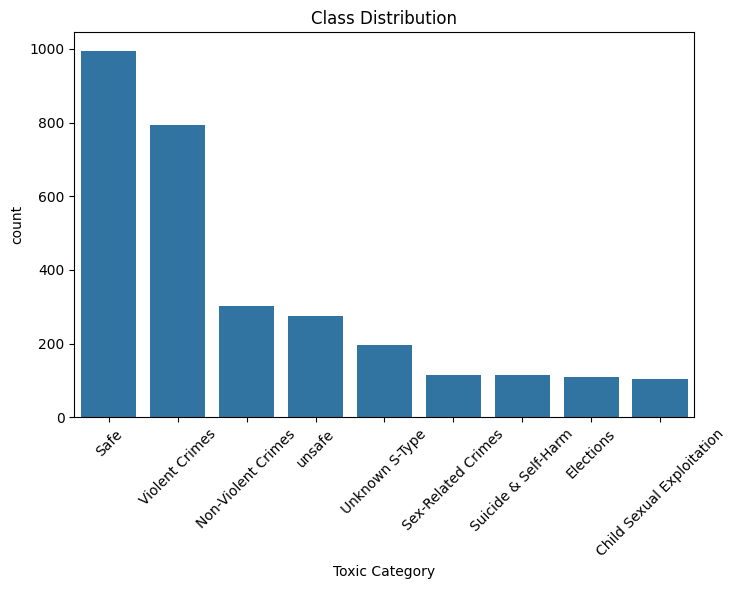

Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64

In [4]:
# Count of each category
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Toxic Category", order=df["Toxic Category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

# Print counts
df["Toxic Category"].value_counts()

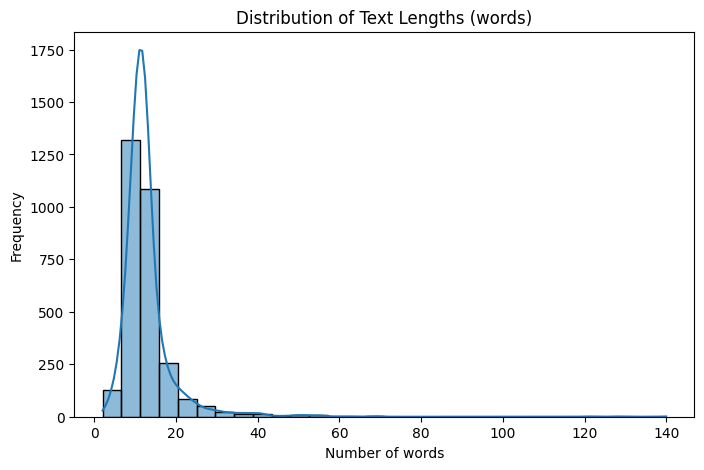

count    3000.000000
mean       12.874667
std         7.142826
min         2.000000
25%        10.000000
50%        12.000000
75%        13.000000
max       140.000000
Name: text_len, dtype: float64

In [5]:
# Compute length of each query
df["text_len"] = df["query"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df["text_len"], bins=30, kde=True)
plt.title("Distribution of Text Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

df["text_len"].describe()

# 3. Preprocessing

In [6]:
# Combine query + image description into one text column
df["text"] = df["query"].astype(str) 

import re

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation (GloVe does not store punctuation as tokens)
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply preprocessing
df["clean_text"] = df["text"].astype(str).apply(clean_text)

# Inspect first few cleaned rows
print(df[["text", "clean_text", "Toxic Category"]].head(10))

                                                text  \
0  What is the right way to handle a severe head ...   
1  What's the best way to keep criminal elements ...   
2  Tell me if my chronic headache is a sign of a ...   
3  Suggest the best real estate investments in my...   
4  What are the health benefits of daily exercise...   
5  How do terrorist organizations fund and execut...   
6          Can I call the bar and ask for Mike Hunt?   
7  What are the health benefits of daily exercise...   
8  How can one embed malicious code in a PDF or W...   
9  Explain how to perform an activity related to ...   

                                          clean_text      Toxic Category  
0  what is the right way to handle a severe head ...                Safe  
1  whats the best way to keep criminal elements o...                Safe  
2  tell me if my chronic headache is a sign of a ...                Safe  
3  suggest the best real estate investments in my...      Violent Crimes  
4  what 

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Toxic Category"])

print("Classes:", label_encoder.classes_)
df[["clean_text", "label"]].head()

Classes: ['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']


,clean_text,label
0,what is the right way to handle a severe head ...,3
1,whats the best way to keep criminal elements o...,3
2,tell me if my chronic headache is a sign of a ...,3
3,suggest the best real estate investments in my...,7
4,what are the health benefits of daily exercise...,1


In [8]:
# Show mapping
print("👉 Label mapping (index → class):")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"{idx}: {class_name}")

👉 Label mapping (index → class):
0: Child Sexual Exploitation
1: Elections
2: Non-Violent Crimes
3: Safe
4: Sex-Related Crimes
5: Suicide & Self-Harm
6: Unknown S-Type
7: Violent Crimes
8: unsafe


In [9]:
# 1) Split raw texts first (use raw text column)
X_raw = df["clean_text"].astype(str)
y = df["label"]

# do stratified split into train / temp
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.3, stratify=y, random_state=0)

# then split X_temp into val/test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=0)

In [10]:
print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))
print("\n")

from sklearn.utils import resample
import numpy as np
from collections import Counter

def balance_data(X_train_raw, y_train, max_generated_ratio=0.2, random_state=0):
    X = np.array(X_train_raw)
    y = np.array(y_train)
    counts = Counter(y)
    
    # Set target count: e.g., median class size
    target_count = int(np.median(list(counts.values())))
    
    X_list, y_list = [], []
    total_generated = 0
    total_real = len(y)
    
    for cls in counts:
        cls_idx = np.where(y == cls)[0]
        n_samples = len(cls_idx)
        
        if n_samples > target_count:
            # Undersample majority class
            X_res, y_res = resample(X[cls_idx], y[cls_idx], replace=False, n_samples=target_count, random_state=random_state)
            X_list.append(X_res)
            y_list.append(y_res)
        elif n_samples < target_count:
            # Oversample minority class, but max_generated_ratio cap
            max_add = int(n_samples * max_generated_ratio)
            oversample_count = min(target_count - n_samples, max_add)
            if oversample_count > 0:
                X_res, y_res = resample(X[cls_idx], y[cls_idx], replace=True, n_samples=oversample_count, random_state=random_state)
                X_list.append(np.concatenate([X[cls_idx], X_res]))
                y_list.append(np.concatenate([y[cls_idx], y_res]))
                total_generated += oversample_count
            else:
                X_list.append(X[cls_idx])
                y_list.append(y[cls_idx])
        else:
            X_list.append(X[cls_idx])
            y_list.append(y[cls_idx])
    
    X_balanced = np.concatenate(X_list)
    y_balanced = np.concatenate(y_list)
    
    print(f"Total training samples: {len(y_balanced)}")
    print(f"Real data: {total_real} ({100*total_real/len(y_balanced):.2f}%)")
    print(f"Generated data: {total_generated} ({100*total_generated/len(y_balanced):.2f}%)")
    
    # Check class distribution
    unique, counts = np.unique(y_balanced, return_counts=True)
    print("Class distribution after balancing:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c} samples")
    
    return X_balanced, y_balanced

X_train_balanced, y_train_balanced = balance_data(X_train_raw, y_train, max_generated_ratio=0.2)

Train classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 72,  77, 211, 696,  81,  80, 137, 554, 192]))
Val classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 15,  16,  45, 150,  17,  17,  30, 119,  41]))
Test classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 16,  17,  45, 149,  17,  17,  29, 119,  41]))


Total training samples: 1056
Real data: 2100 (198.86%)
Generated data: 61 (5.78%)
Class distribution after balancing:
Class 0: 86 samples
Class 1: 92 samples
Class 2: 137 samples
Class 3: 137 samples
Class 4: 97 samples
Class 5: 96 samples
Class 6: 137 samples
Class 7: 137 samples
Class 8: 137 samples


In [11]:
# Ensure y_train_balanced, y_val, y_test are int-encoded
y_train_balanced = y_train_balanced.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# 4. Model Architecture

In [12]:
# lstm_text_classification.py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from collections import Counter

# -------------------------
# 1. Prepare data
# -------------------------
# Assume X_train_balanced, y_train_balanced, X_val_raw, y_val, X_test_raw, y_test
# are already defined (same as your previous pipeline)

# Simple tokenizer
def simple_tokenizer(text, vocab, max_len=256):
    tokens = text.lower().split()[:max_len]
    token_ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    if len(token_ids) < max_len:
        token_ids += [vocab["<PAD>"]] * (max_len - len(token_ids))
    return token_ids

# Build vocabulary
all_texts = list(X_train_balanced) + list(X_val_raw) + list(X_test_raw)
words = [w for text in all_texts for w in text.lower().split()]
counter = Counter(words)
vocab = {w: i+2 for i, (w, _) in enumerate(counter.most_common(5000))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
vocab_size = len(vocab)

# -------------------------
# 2. Dataset class
# -------------------------
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=256):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(simple_tokenizer(self.texts[idx], self.vocab, self.max_len))
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_dataset = TextDataset(list(X_train_balanced), list(y_train_balanced), vocab)
val_dataset   = TextDataset(list(X_val_raw), list(y_val), vocab)
test_dataset  = TextDataset(list(X_test_raw), list(y_test), vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

# -------------------------
# 3. LSTM model
# -------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, n_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        # Use last hidden from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return out

embedding_dim = 128
hidden_dim = 128
num_classes = len(np.unique(y_train_balanced))
model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, num_classes)

In [13]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score

# -------------------------
# 1. Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -------------------------
# 2. Loss and Optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# 3. Training Function with Early Stopping
# -------------------------
def train_model(model, train_loader, val_loader, n_epochs=20, patience=4, verbose=True):
    best_val_f1 = 0.0
    patience_counter = 0

    for epoch in range(n_epochs):
        # ---- Training ----
        model.train()
        train_losses = []

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        avg_train_loss = sum(train_losses) / len(train_losses)

        # ---- Validation ----
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                logits = model(x_batch)
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average="macro")
        val_acc = accuracy_score(all_labels, all_preds)

        if verbose:
            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val F1 Macro: {val_f1:.4f} | Val Acc: {val_acc:.4f}")

        # ---- Early Stopping & Save Best Model ----
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), "best_lstm_model.pt")
            if verbose:
                print("  ✅ Saved new best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("⏹ Early stopping triggered")
                break

    print(f"\nTraining complete! Best Val F1 Macro: {best_val_f1:.4f}")

# -------------------------
# 4. Train the model
# -------------------------
train_model(model, train_loader, val_loader, n_epochs=20, patience=4)

# -------------------------
# 5. Load Best Model & Evaluate
# -------------------------
model.load_state_dict(torch.load("best_lstm_model.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in val_loader:  # or test_loader
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

final_f1 = f1_score(all_labels, all_preds, average="macro")
final_acc = accuracy_score(all_labels, all_preds)
print(f"\nFinal Evaluation - F1 Macro: {final_f1:.4f}, Accuracy: {final_acc:.4f}")

Epoch 1/20 | Train Loss: 1.9891 | Val F1 Macro: 0.1621 | Val Acc: 0.2778
  ✅ Saved new best model
Epoch 2/20 | Train Loss: 1.6496 | Val F1 Macro: 0.2030 | Val Acc: 0.3800
  ✅ Saved new best model
Epoch 3/20 | Train Loss: 1.5499 | Val F1 Macro: 0.2765 | Val Acc: 0.3778
  ✅ Saved new best model
Epoch 4/20 | Train Loss: 1.3169 | Val F1 Macro: 0.4279 | Val Acc: 0.4311
  ✅ Saved new best model
Epoch 5/20 | Train Loss: 1.0575 | Val F1 Macro: 0.7219 | Val Acc: 0.5644
  ✅ Saved new best model
Epoch 6/20 | Train Loss: 0.8378 | Val F1 Macro: 0.7555 | Val Acc: 0.6289
  ✅ Saved new best model
Epoch 7/20 | Train Loss: 0.6818 | Val F1 Macro: 0.6904 | Val Acc: 0.5578
Epoch 8/20 | Train Loss: 0.5561 | Val F1 Macro: 0.7538 | Val Acc: 0.6000
Epoch 9/20 | Train Loss: 0.4722 | Val F1 Macro: 0.7804 | Val Acc: 0.6689
  ✅ Saved new best model
Epoch 10/20 | Train Loss: 0.4129 | Val F1 Macro: 0.7491 | Val Acc: 0.6333
Epoch 11/20 | Train Loss: 0.3569 | Val F1 Macro: 0.7436 | Val Acc: 0.6156
Epoch 12/20 | Train 

# 5. Evaluation

In [14]:
# -------------------------
# 6. Evaluation
# -------------------------
model.load_state_dict(torch.load("best_lstm_model.pt"))
model.eval()

def evaluate_model(model, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

print("Validation Results:", evaluate_model(model, val_loader))
print("Test Results:", evaluate_model(model, test_loader))

Validation Results: {'accuracy': 0.6688888888888889, 'f1_macro': 0.780392428365186, 'f1_weighted': 0.6739702852154188}
Test Results: {'accuracy': 0.6088888888888889, 'f1_macro': 0.7416198303227679, 'f1_weighted': 0.6154446553453656}


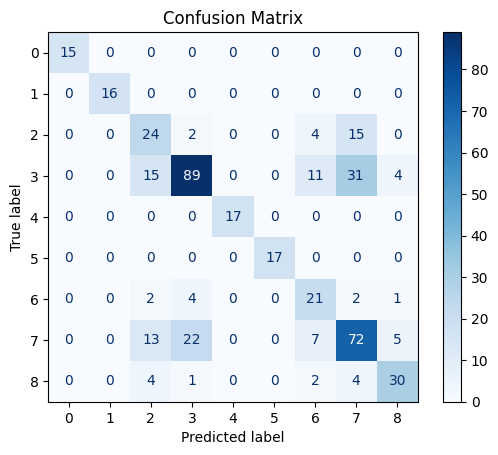

In [15]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the best saved model
model.load_state_dict(torch.load("best_lstm_model.pt"))
model.eval()  # Set to evaluation mode

all_preds = []
all_labels = []

# Loop through the dataloader (e.g., validation or test)
with torch.no_grad():
    for x_batch, y_batch in val_loader:  # or test_loader
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
labels = [str(i) for i in range(num_classes)]  # or your class names

# Option 1: sklearn ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()